<a href="https://colab.research.google.com/github/muditkumar14/aiml/blob/main/eda-assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Task 1

In [3]:
df.shape

(200, 6)

In [4]:
df.dtypes

,0
order_id,int64
city,object
category,object
order_value,float64
delivery_days,float64
rating,object


In [8]:
df.isna().sum()

,0
order_id,0
city,0
category,0
order_value,14
delivery_days,10
rating,32


In [16]:
(((df.isna().sum())/len(df))*100).round(2)

,0
order_id,0.0
city,0.0
category,0.0
order_value,7.0
delivery_days,5.0
rating,16.0


Task 2

In [17]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


1. Maximum and minimum order value 95000 and 204
2. Maximum and minimum delivery day 14 and 1 day
3. Total order count is 200

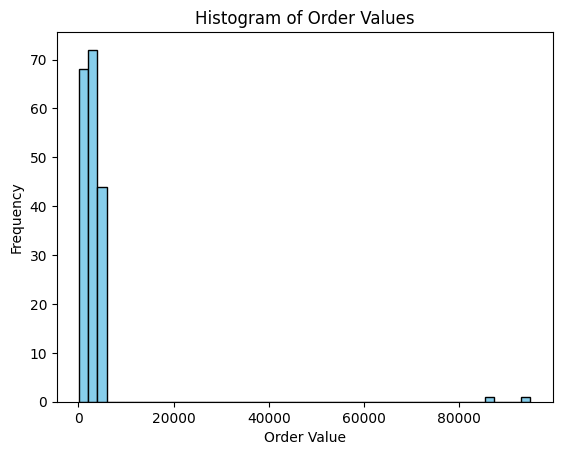

In [27]:
import matplotlib.pyplot as plt
plt.hist(data=df,x='order_value',bins=50,edgecolor='black', color='skyblue')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.title('Histogram of Order Values')
plt.show()

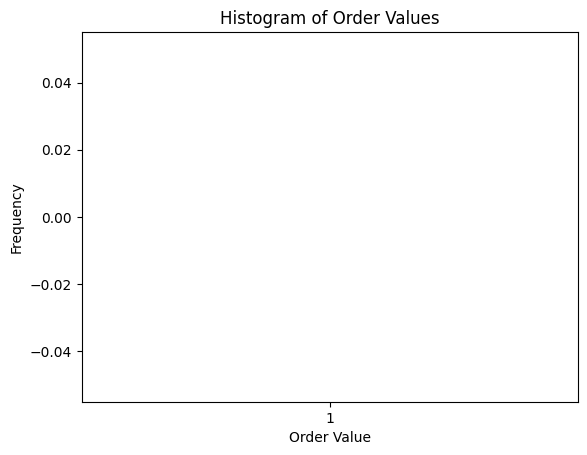

In [29]:
plt.boxplot(data=df,x='delivery_days')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.title('Histogram of Order Values')
plt.show()

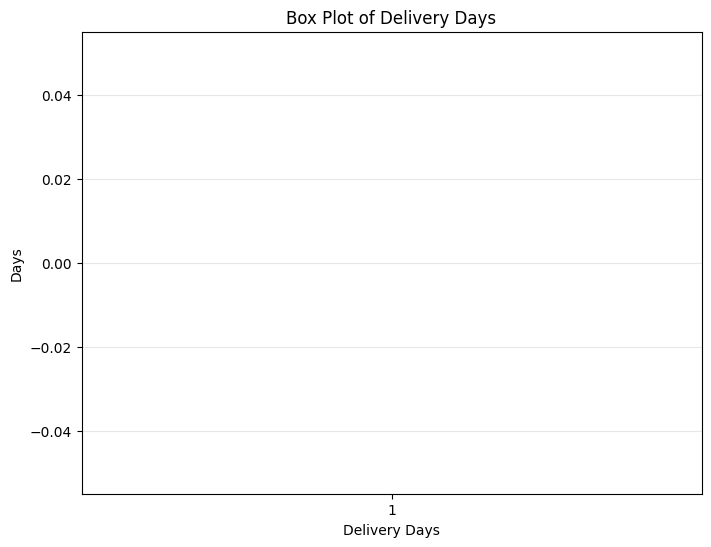

In [28]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['delivery_days'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.xlabel('Delivery Days')
plt.ylabel('Days')
plt.title('Box Plot of Delivery Days')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [37]:
cd=df.corr(numeric_only=True)
cd

,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


<Axes: >

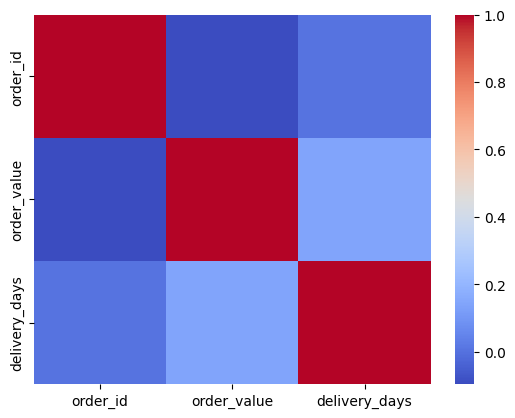

In [44]:
from matplotlib.colors import Colormap
import seaborn as sns
sns.heatmap(data=cd,cmap='coolwarm')

order_value and delivery_days show a weak to moderate positive correlation